In [1]:
import importlib
import numpy as np
import seaborn as sns
sns.set_theme()
import matplotlib.pyplot as plt

# adjust path
path_to_hkpt = '../'
import sys
sys.path.append(path_to_hkpt)

import hk_parallel_transport as hkpt
hkpt = importlib.reload(hkpt)

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})


/home/tsaidi/research/Sp26/HKPT/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Scaled mean_1: [0.], Scaled sigma_1: 0.20386592349202756
Scaled mean_2: [0.], Scaled sigma_2: 0.20386592349202756
Scaled mean_3: [0.], Scaled sigma_3: 0.20386592349202756
Transporting step 1/4...
Transporting step 2/4...
Transporting step 3/4...
Transporting step 4/4...
Parallel transport alignment succeeded
mu1 mean: -0.013866829292437882, mu1 var: 0.21101393927604511
mu2 mean: -0.01570900528777482, mu2 var: 0.19742749998659567
mu3 mean: -0.00870693874755627, mu3 var: 0.20812396383005383
mu4_at_mu3 mean: -0.010977151719855015, mu4_at_mu3 var: 0.19223325714295486
mu1 mass: 500.0
mu2 mass: 1000.0
mu3 mass: 1000.0
mu4_at_mu3 mass: 1667.193490944083
HK distance between mu1 and mu2: 9.348337039979478
HK distance between mu3 and mu4_at_mu3: 9.363385690409926


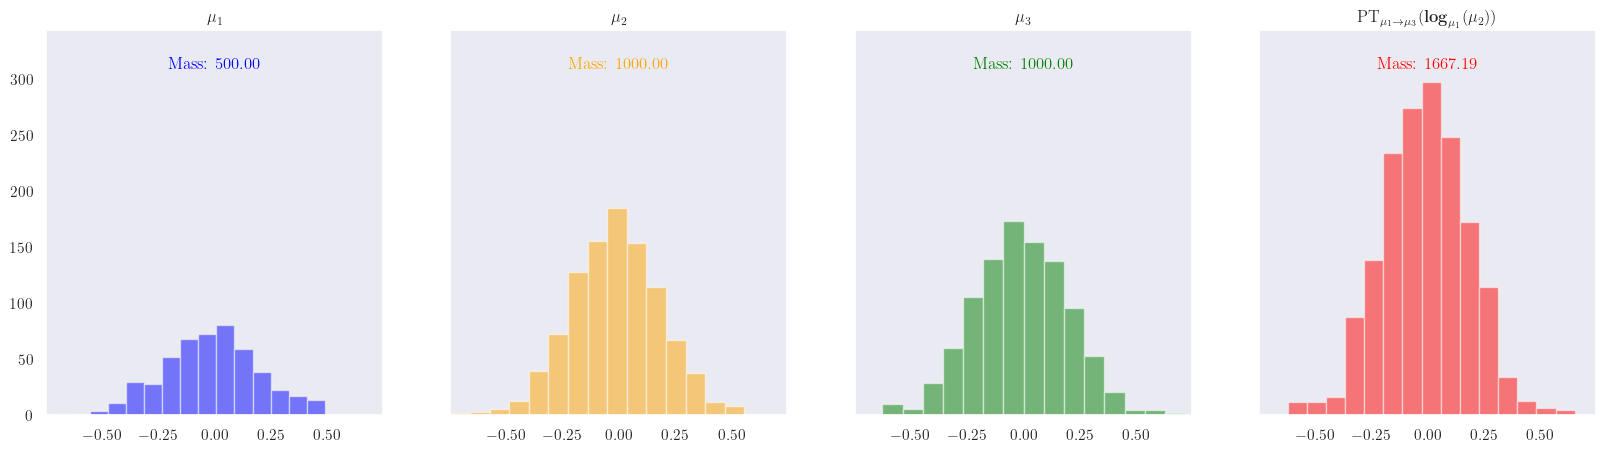

In [2]:
n_1 = 500
n_2 = 1000
n_3 = 1000

mean_1 = np.array([0.0])
cov_1 = np.array([[2.0]])
mean_2 = np.array([0.0])
cov_2 = np.array([[2.0]])
mean_3 = np.array([0.0])
cov_3 = np.array([[2.0]])

data_1 = np.random.multivariate_normal(mean_1, cov_1, n_1)
data_2 = np.random.multivariate_normal(mean_2, cov_2, n_2)
data_3 = np.random.multivariate_normal(mean_3, cov_3, n_3)

# scale everything to < pi/4
max_val = max(np.max(data_1), np.max(data_2), np.max(data_3))
min_val = min(np.min(data_1), np.min(data_2), np.min(data_3))
scale_factor = ((np.pi / 2) - 1e-1) / (max_val - min_val)
data_1 *= scale_factor
data_2 *= scale_factor
data_3 *= scale_factor
# print(scaled means and covariances)
print(f"Scaled mean_1: {mean_1 * scale_factor}, Scaled sigma_1: {np.sqrt(cov_1[0, 0]) * scale_factor}")
print(f"Scaled mean_2: {mean_2 * scale_factor}, Scaled sigma_2: {np.sqrt(cov_2[0, 0]) * scale_factor}")
print(f"Scaled mean_3: {mean_3 * scale_factor}, Scaled sigma_3: {np.sqrt(cov_3[0, 0]) * scale_factor}")

mu1 = hkpt.EmpiricalMeasure(data_1, weights=np.ones(n_1))
mu2 = hkpt.EmpiricalMeasure(data_2, weights=np.ones(n_2))
mu3 = hkpt.EmpiricalMeasure(data_3, weights=np.ones(n_3))

tangent_12 = hkpt.hk_logarithmic_map(
    mu1,
    mu2, 
    allow_approximation=True, 
    approximation_mode='barycentric',
)


# parallel transport tangent_12 from mu1 to mu3
tangent_12_at_mu3, pt_alignment_diag = hkpt.hk_parallel_transport(
    mu1,
    mu3,
    tangent_12,
    N = 4,
    return_alignment_diagnostics=True,
)

if pt_alignment_diag['alignment_succeeded']:
    print(f"Parallel transport alignment succeeded")
else:
    print(f"Parallel transport alignment failed with final alignment error {pt_alignment_diag['nearest_neighbor_distances'].max()}")

mu4_at_mu3 = hkpt.hk_exponential_map(mu3, tangent_12_at_mu3)

# plot all four measures on the four different subplots in one row as unnormalized histograms with weights from the empirical measures
fig, axs = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
axs[0].hist(data_1.flatten(), bins=15, weights=mu1.weights, label=r'$\mu_1$', color='blue', alpha=0.5);
axs[0].set_title(r'$\mu_1$')
axs[1].hist(data_2.flatten(), bins=15, weights=mu2.weights, label=r'$\mu_2$', color='orange', alpha=0.5);
axs[1].set_title(r'$\mu_2$')
axs[2].hist(data_3.flatten(), bins=15, weights=mu3.weights, label=r'$\mu_3$', color='green', alpha=0.5);
axs[2].set_title(r'$\mu_3$')
if mu4_at_mu3 is not None:
    axs[3].hist(mu4_at_mu3.samples.flatten(), bins=15, weights=mu4_at_mu3.weights, label=r'$\mathrm{PT}_{\mu_1 \rightarrow \mu_3}(\mathbf{log}_{\mu_1}(\mu_2))$', color='red', alpha=0.5);
    axs[3].set_title(r'$\mathrm{PT}_{\mu_1 \rightarrow \mu_3}(\mathbf{log}_{\mu_1}(\mu_2))$')
# increase ylim a bit
plt.ylim(0, plt.ylim()[1] * 1.1)

# print means and variances of all measures
print(f"mu1 mean: {np.mean(mu1.samples.flatten())}, mu1 var: {np.mean((mu1.samples.flatten() - np.mean(mu1.samples.flatten() ))**2 ) ** 0.5}")
print(f"mu2 mean: {np.mean(mu2.samples.flatten())}, mu2 var: {np.mean((mu2.samples.flatten() - np.mean(mu2.samples.flatten() ))**2 ) ** 0.5}")
print(f"mu3 mean: {np.mean(mu3.samples.flatten())}, mu3 var: {np.mean((mu3.samples.flatten() - np.mean(mu3.samples.flatten() ))**2 ) ** 0.5}")
if mu4_at_mu3 is not None:
    print(f"mu4_at_mu3 mean: {np.mean(mu4_at_mu3.samples.flatten())}, mu4_at_mu3 var: {np.mean((mu4_at_mu3.samples.flatten() - np.mean(mu4_at_mu3.samples.flatten() ))**2 ) ** 0.5}")

# add text to each subplot with the mass (sum of weights) of each measure
axs[0].text(0.5, 0.9, f"Mass: {mu1.weights.sum():.2f}", transform=axs[0].transAxes, color='blue', ha='center')
axs[1].text(0.5, 0.9, f"Mass: {mu2.weights.sum():.2f}", transform=axs[1].transAxes, color='orange', ha='center')
axs[2].text(0.5, 0.9, f"Mass: {mu3.weights.sum():.2f}", transform=axs[2].transAxes, color='green', ha='center')
if mu4_at_mu3 is not None:
    axs[3].text(0.5, 0.9, f"Mass: {mu4_at_mu3.weights.sum():.2f}", transform=axs[3].transAxes, color='red', ha='center')

all_hist_samples = [
    mu1.samples.flatten(),
    mu2.samples.flatten(),
    mu3.samples.flatten(),
]
if mu4_at_mu3 is not None:
    all_hist_samples.append(mu4_at_mu3.samples.flatten())
max_abs_x = np.max(np.abs(np.concatenate(all_hist_samples)))
for ax in axs:
    ax.set_xlim(-max_abs_x, max_abs_x)

# get rid of grid lines
for ax in axs:
    ax.grid(False)

# save figure
plt.savefig('../Figures/HK_parallel_transport_1d_mass_increase_no_mean_shift.pdf', dpi=800)

# print mass of all measures
print(f"mu1 mass: {mu1.weights.sum()}")
print(f"mu2 mass: {mu2.weights.sum()}")
print(f"mu3 mass: {mu3.weights.sum()}")
if mu4_at_mu3 is not None:
    print(f"mu4_at_mu3 mass: {mu4_at_mu3.weights.sum()}")

# print HK distance between mu1 and mu3, and between mu1 and mu3_at_mu1
hk_distance_mu1_mu2 = hkpt.hk_distance(mu1, mu2)
hk_distance_mu3_mu4_at_mu3 = hkpt.hk_distance(mu3, mu4_at_mu3)
print(f"HK distance between mu1 and mu2: {hk_distance_mu1_mu2}")
print(f"HK distance between mu3 and mu4_at_mu3: {hk_distance_mu3_mu4_at_mu3}")


Scaled mean_1: [0.], Scaled sigma_1: 0.20102487343114367
Scaled mean_2: [0.], Scaled sigma_2: 0.20102487343114367
Scaled mean_3: [0.], Scaled sigma_3: 0.20102487343114367
Transporting step 1/4...
Transporting step 2/4...
Transporting step 3/4...
Transporting step 4/4...
Parallel transport alignment succeeded
mu1 mean: 0.009781422729331947, mu1 var: 0.20569422211157198
mu2 mean: 0.008527348590440095, mu2 var: 0.20686690390513357
mu3 mean: -0.0020877837231444026, mu3 var: 0.19423971163615544
mu4_at_mu3 mean: -0.005457079803624722, mu4_at_mu3 var: 0.19430308220976503
mu1 mass: 1000.0
mu2 mass: 500.0
mu3 mass: 2000.0
mu4_at_mu3 mass: 1258.5412330961246
HK distance between mu1 and mu2: 9.34070823477439
HK distance between mu3 and mu4_at_mu3: 9.414265257011923


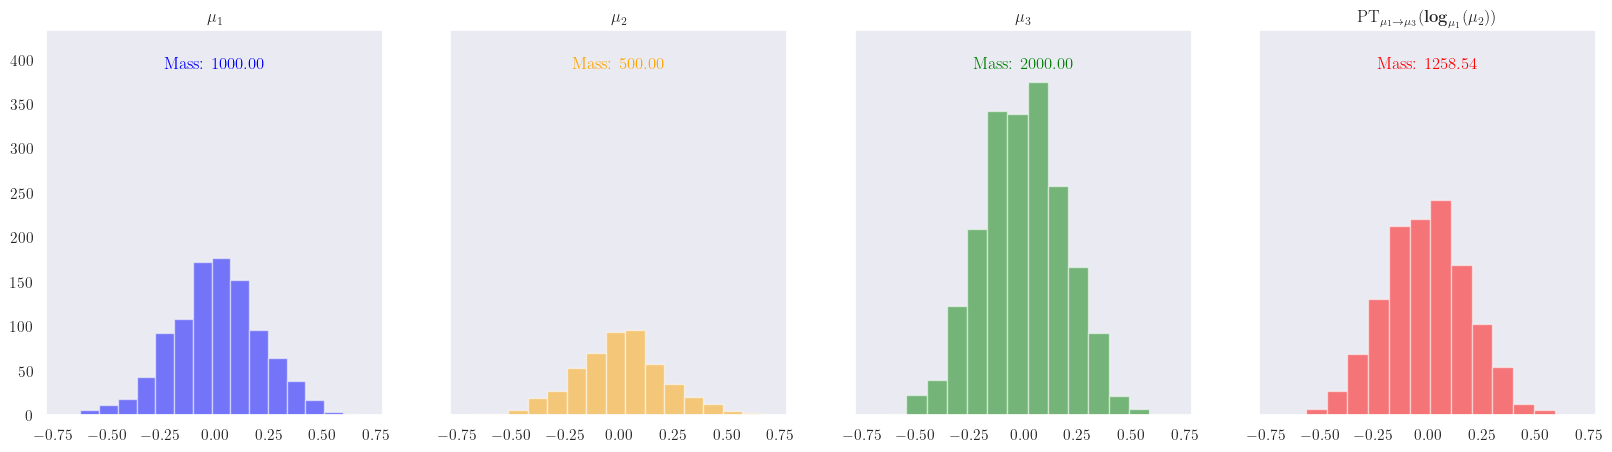

In [3]:
n_1 = 1000
n_2 = 500
n_3 = 2000

mean_1 = np.array([0.0])
cov_1 = np.array([[2.0]])
mean_2 = np.array([0.0])
cov_2 = np.array([[2.0]])
mean_3 = np.array([0.0])
cov_3 = np.array([[2.0]])

data_1 = np.random.multivariate_normal(mean_1, cov_1, n_1)
data_2 = np.random.multivariate_normal(mean_2, cov_2, n_2)
data_3 = np.random.multivariate_normal(mean_3, cov_3, n_3)

# scale everything to < pi/4
max_val = max(np.max(data_1), np.max(data_2), np.max(data_3))
min_val = min(np.min(data_1), np.min(data_2), np.min(data_3))
scale_factor = ((np.pi / 2) - 1e-1) / (max_val - min_val)
data_1 *= scale_factor
data_2 *= scale_factor
data_3 *= scale_factor
# print(scaled means and covariances)
print(f"Scaled mean_1: {mean_1 * scale_factor}, Scaled sigma_1: {np.sqrt(cov_1[0, 0]) * scale_factor}")
print(f"Scaled mean_2: {mean_2 * scale_factor}, Scaled sigma_2: {np.sqrt(cov_2[0, 0]) * scale_factor}")
print(f"Scaled mean_3: {mean_3 * scale_factor}, Scaled sigma_3: {np.sqrt(cov_3[0, 0]) * scale_factor}")

mu1 = hkpt.EmpiricalMeasure(data_1, weights=np.ones(n_1))
mu2 = hkpt.EmpiricalMeasure(data_2, weights=np.ones(n_2))
mu3 = hkpt.EmpiricalMeasure(data_3, weights=np.ones(n_3))

tangent_12 = hkpt.hk_logarithmic_map(
    mu1,
    mu2, 
    allow_approximation=True, 
    approximation_mode='barycentric',
)


# parallel transport tangent_12 from mu1 to mu3
tangent_12_at_mu3, pt_alignment_diag = hkpt.hk_parallel_transport(
    mu1,
    mu3,
    tangent_12,
    N = 4,
    return_alignment_diagnostics=True,
)

if pt_alignment_diag['alignment_succeeded']:
    print(f"Parallel transport alignment succeeded")
else:
    print(f"Parallel transport alignment failed with final alignment error {pt_alignment_diag['nearest_neighbor_distances'].max()}")

mu4_at_mu3 = hkpt.hk_exponential_map(mu3, tangent_12_at_mu3)

# plot all four measures on the four different subplots in one row as unnormalized histograms with weights from the empirical measures
fig, axs = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
axs[0].hist(data_1.flatten(), bins=15, weights=mu1.weights, label=r'$\mu_1$', color='blue', alpha=0.5);
axs[0].set_title(r'$\mu_1$')
axs[1].hist(data_2.flatten(), bins=15, weights=mu2.weights, label=r'$\mu_2$', color='orange', alpha=0.5);
axs[1].set_title(r'$\mu_2$')
axs[2].hist(data_3.flatten(), bins=15, weights=mu3.weights, label=r'$\mu_3$', color='green', alpha=0.5);
axs[2].set_title(r'$\mu_3$')
if mu4_at_mu3 is not None:
    axs[3].hist(mu4_at_mu3.samples.flatten(), bins=15, weights=mu4_at_mu3.weights, label=r'$\mathrm{PT}_{\mu_1 \rightarrow \mu_3}(\mathbf{log}_{\mu_1}(\mu_2))$', color='red', alpha=0.5);
    axs[3].set_title(r'$\mathrm{PT}_{\mu_1 \rightarrow \mu_3}(\mathbf{log}_{\mu_1}(\mu_2))$')
# increase ylim a bit
plt.ylim(0, plt.ylim()[1] * 1.1)

# print means and variances of all measures
print(f"mu1 mean: {np.mean(mu1.samples.flatten())}, mu1 var: {np.mean((mu1.samples.flatten() - np.mean(mu1.samples.flatten() ))**2 ) ** 0.5}")
print(f"mu2 mean: {np.mean(mu2.samples.flatten())}, mu2 var: {np.mean((mu2.samples.flatten() - np.mean(mu2.samples.flatten() ))**2 ) ** 0.5}")
print(f"mu3 mean: {np.mean(mu3.samples.flatten())}, mu3 var: {np.mean((mu3.samples.flatten() - np.mean(mu3.samples.flatten() ))**2 ) ** 0.5}")
if mu4_at_mu3 is not None:
    print(f"mu4_at_mu3 mean: {np.mean(mu4_at_mu3.samples.flatten())}, mu4_at_mu3 var: {np.mean((mu4_at_mu3.samples.flatten() - np.mean(mu4_at_mu3.samples.flatten() ))**2 ) ** 0.5}")

# add text to each subplot with the mass (sum of weights) of each measure
axs[0].text(0.5, 0.9, f"Mass: {mu1.weights.sum():.2f}", transform=axs[0].transAxes, color='blue', ha='center')
axs[1].text(0.5, 0.9, f"Mass: {mu2.weights.sum():.2f}", transform=axs[1].transAxes, color='orange', ha='center')
axs[2].text(0.5, 0.9, f"Mass: {mu3.weights.sum():.2f}", transform=axs[2].transAxes, color='green', ha='center')
if mu4_at_mu3 is not None:
    axs[3].text(0.5, 0.9, f"Mass: {mu4_at_mu3.weights.sum():.2f}", transform=axs[3].transAxes, color='red', ha='center')

all_hist_samples = [
    mu1.samples.flatten(),
    mu2.samples.flatten(),
    mu3.samples.flatten(),
]
if mu4_at_mu3 is not None:
    all_hist_samples.append(mu4_at_mu3.samples.flatten())
max_abs_x = np.max(np.abs(np.concatenate(all_hist_samples)))
for ax in axs:
    ax.set_xlim(-max_abs_x, max_abs_x)

# get rid of grid lines
for ax in axs:
    ax.grid(False)

# save figure
plt.savefig('../Figures/HK_parallel_transport_1d_mass_decrease_no_mean_shift.pdf', dpi=800)


# print mass of all measures
print(f"mu1 mass: {mu1.weights.sum()}")
print(f"mu2 mass: {mu2.weights.sum()}")
print(f"mu3 mass: {mu3.weights.sum()}")
if mu4_at_mu3 is not None:
    print(f"mu4_at_mu3 mass: {mu4_at_mu3.weights.sum()}")

# print HK distance between mu1 and mu3, and between mu1 and mu3_at_mu1
hk_distance_mu1_mu2 = hkpt.hk_distance(mu1, mu2)
hk_distance_mu3_mu4_at_mu3 = hkpt.hk_distance(mu3, mu4_at_mu3)
print(f"HK distance between mu1 and mu2: {hk_distance_mu1_mu2}")
print(f"HK distance between mu3 and mu4_at_mu3: {hk_distance_mu3_mu4_at_mu3}")


Scaled mean_1: [0.], Scaled sigma_1: 0.04206887713496047
Scaled mean_2: [0.89241565], Scaled sigma_2: 0.04206887713496047
Scaled mean_3: [1.18988753], Scaled sigma_3: 0.04206887713496047


mu3 mean: 1.1908375457477869, mu3 var: 0.03986585457911154
mu3_at_mu2 mean: 1.1895586340186497, mu3_at_mu2 var: 0.023858029962254206
Transporting step 1/4...
Transporting step 2/4...
Transporting step 3/4...
Transporting step 4/4...
Parallel transport alignment succeeded
HK distance between mu2 and mu3: 9.41965871479597
HK distance between mu1 and mu3_at_mu1: 9.392948521498788


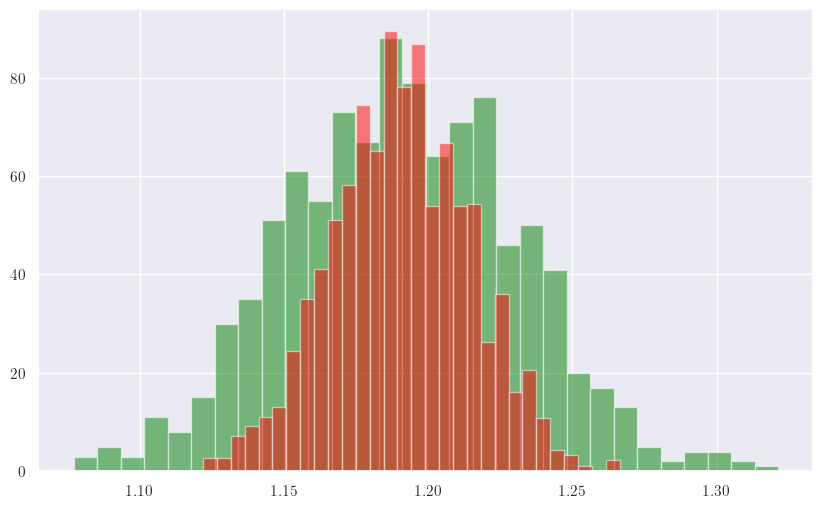

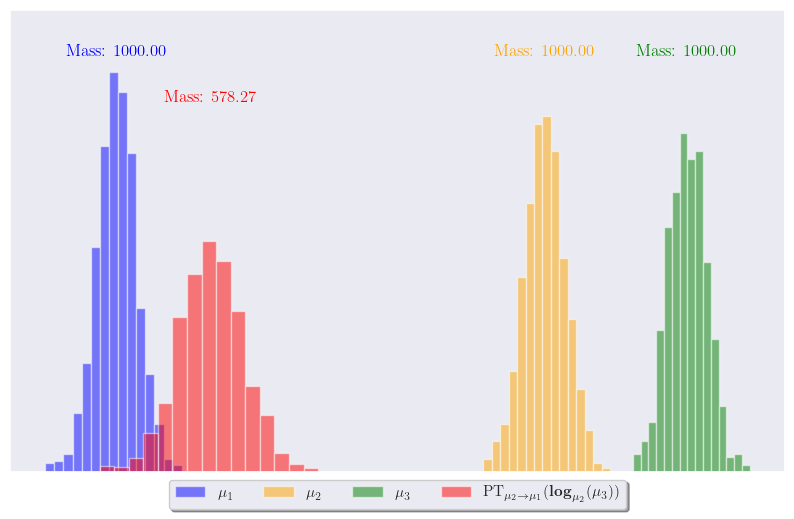

In [4]:
n_1 = 1000
n_2 = 1000
n_3 = 1000

mean_1 = np.array([0.0])
cov_1 = np.array([[2.0]])
mean_2 = np.array([30.0])
cov_2 = np.array([[2.0]])
mean_3 = np.array([40.0])
cov_3 = np.array([[2.0]])

data_1 = np.random.multivariate_normal(mean_1, cov_1, n_1)
data_2 = np.random.multivariate_normal(mean_2, cov_2, n_2)
data_3 = np.random.multivariate_normal(mean_3, cov_3, n_3)

# scale everything to < pi/4
max_val = max(np.max(data_1), np.max(data_2), np.max(data_3))
min_val = min(np.min(data_1), np.min(data_2), np.min(data_3))
scale_factor = ((np.pi / 2) - 1e-1) / (max_val - min_val)

data_1_scaled = data_1 * scale_factor
data_2_scaled = data_2 * scale_factor
data_3_scaled = data_3 * scale_factor
# print(scaled means and covariances)
print(f"Scaled mean_1: {mean_1 * scale_factor}, Scaled sigma_1: {np.sqrt(cov_1[0, 0]) * scale_factor}")
print(f"Scaled mean_2: {mean_2 * scale_factor}, Scaled sigma_2: {np.sqrt(cov_2[0, 0]) * scale_factor}")
print(f"Scaled mean_3: {mean_3 * scale_factor}, Scaled sigma_3: {np.sqrt(cov_3[0, 0]) * scale_factor}")

mu1 = hkpt.EmpiricalMeasure(data_1_scaled, weights=np.ones(n_1))
mu2 = hkpt.EmpiricalMeasure(data_2_scaled, weights=np.ones(n_2))
mu3 = hkpt.EmpiricalMeasure(data_3_scaled, weights=np.ones(n_3))

tangent_23 = hkpt.hk_logarithmic_map(
    mu2,
    mu3,
    allow_approximation=True,
    approximation_mode='barycentric',
)

# diagnostic: plot mu3 and mu3_hat = exp(log(mu2, mu3)) on the same scaled coordinates
mu3_at_mu2 = hkpt.hk_exponential_map(mu2, tangent_23)
plt.figure(figsize=(10, 6))
plt.hist(mu3.samples.flatten(), bins=30, weights=mu3.weights, label=r'$\mu_3$', color='green', alpha=0.5)
plt.hist(mu3_at_mu2.samples.flatten(), bins=30, weights=mu3_at_mu2.weights, label=r'$\hat{\mu}_3 = \exp_{\mu_2}(\log_{\mu_2}(\mu_3))$', color='red', alpha=0.5)

# print mean and var of mu3 and mu3_at_mu2 locations (not weights)
print(f"mu3 mean: {np.mean(mu3.samples.flatten())}, mu3 var: {np.mean((mu3.samples.flatten() - np.mean(mu3.samples.flatten() ))**2 ) ** 0.5}")
print(f"mu3_at_mu2 mean: {np.mean(mu3_at_mu2.samples.flatten())}, mu3_at_mu2 var: {np.mean((mu3_at_mu2.samples.flatten() - np.mean(mu3_at_mu2.samples.flatten() ))**2 ) ** 0.5}")

# parallel transport tangent_23 from mu2 to mu1
tangent_23_at_mu1, pt_alignment_diag = hkpt.hk_parallel_transport(
    mu2,
    mu1,
    tangent_23,
    N = 4,
    return_alignment_diagnostics=True,
)

if pt_alignment_diag['alignment_succeeded']:
    print(f"Parallel transport alignment succeeded")
else:
    print(f"Parallel transport alignment failed with final alignment error {pt_alignment_diag['nearest_neighbor_distances'].max()}")

mu3_at_mu1 = hkpt.hk_exponential_map(mu1, tangent_23_at_mu1)

# plot all four measures on the same plot as unnormalized histograms with weights from the empirical measures
plt.figure(figsize=(10, 6))
plt.hist(data_1_scaled.flatten(), bins=15, weights=mu1.weights, label=r'$\mu_1$', color='blue', alpha=0.5)
plt.hist(data_2_scaled.flatten(), bins=15, weights=mu2.weights, label=r'$\mu_2$', color='orange', alpha=0.5)
plt.hist(data_3_scaled.flatten(), bins=15, weights=mu3.weights, label=r'$\mu_3$', color='green', alpha=0.5)
if mu3_at_mu1 is not None:
    plt.hist(mu3_at_mu1.samples.flatten(), bins=15, weights=mu3_at_mu1.weights, label=r'$\mathrm{PT}_{\mu_2 \rightarrow \mu_1}(\mathbf{log}_{\mu_2}(\mu_3))$', color='red', alpha=0.5)
# add legend underneath the plot
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.0),
    fancybox=True,
    shadow=True,
    ncol=4,
)
# no ticks
plt.xticks([])
plt.yticks([])
plt.ylim(0, plt.ylim()[1] * 1.1)
# add floating text at the mean of each distribution with total mass (sum of weights) in legend
x_mu1 = float(np.ravel(mean_1)[0]) * scale_factor
x_mu2 = float(np.ravel(mean_2)[0]) * scale_factor
x_mu3 = float(np.ravel(mean_3)[0]) * scale_factor
plt.text(x_mu1, plt.ylim()[1] * 0.9, f"Mass: {mu1.weights.sum():.2f}", color='blue', ha='center')
plt.text(x_mu2, plt.ylim()[1] * 0.9, f"Mass: {mu2.weights.sum():.2f}", color='orange', ha='center')
plt.text(x_mu3, plt.ylim()[1] * 0.9, f"Mass: {mu3.weights.sum():.2f}", color='green', ha='center')
if mu3_at_mu1 is not None:
    plt.text(np.mean(mu3_at_mu1.samples.flatten()), plt.ylim()[1] * 0.8, f"Mass: {mu3_at_mu1.weights.sum():.2f}", color='red', ha='center')
plt.savefig(f'../Figures/HK_parallel_transport_1d_mean_shift.pdf', dpi=800)

# print HK distance between mu1 and mu3, and between mu1 and mu3_at_mu1
hk_distance_mu2_mu3 = hkpt.hk_distance(mu2, mu3)
hk_distance_mu1_mu3_at_mu1 = hkpt.hk_distance(mu1, mu3_at_mu1)
print(f"HK distance between mu2 and mu3: {hk_distance_mu2_mu3}")
print(f"HK distance between mu1 and mu3_at_mu1: {hk_distance_mu1_mu3_at_mu1}")

Scaled mean_1: [0.], Scaled sigma_1: 0.11593462589470226
Scaled mean_2: [0.], Scaled sigma_2: 0.16395632028893894
Scaled mean_3: [0.], Scaled sigma_3: 0.2318692517894045


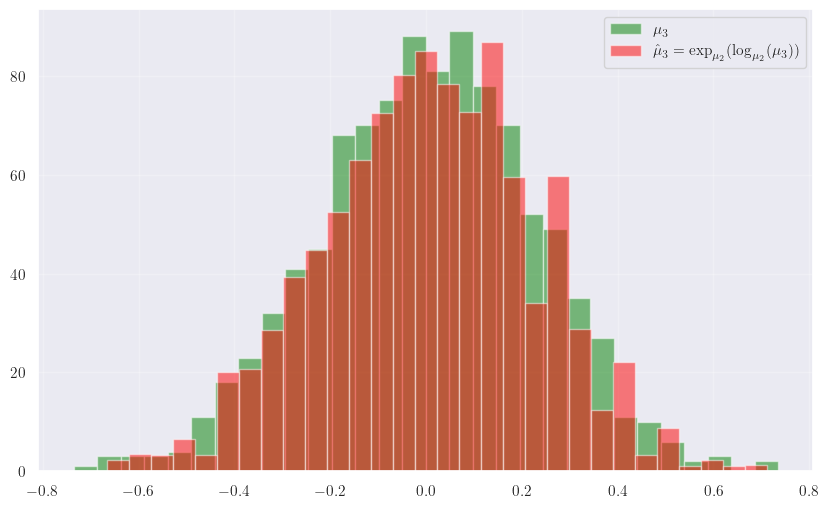

mu3 mean: 0.004574014956505394, mu3 var: 0.22560014077096688
mu3_at_mu2 mean: 0.004688940512141692, mu3_at_mu2 var: 0.21538358612012984
Transporting step 1/4...
Transporting step 2/4...
Transporting step 3/4...
Transporting step 4/4...
Parallel transport alignment succeeded


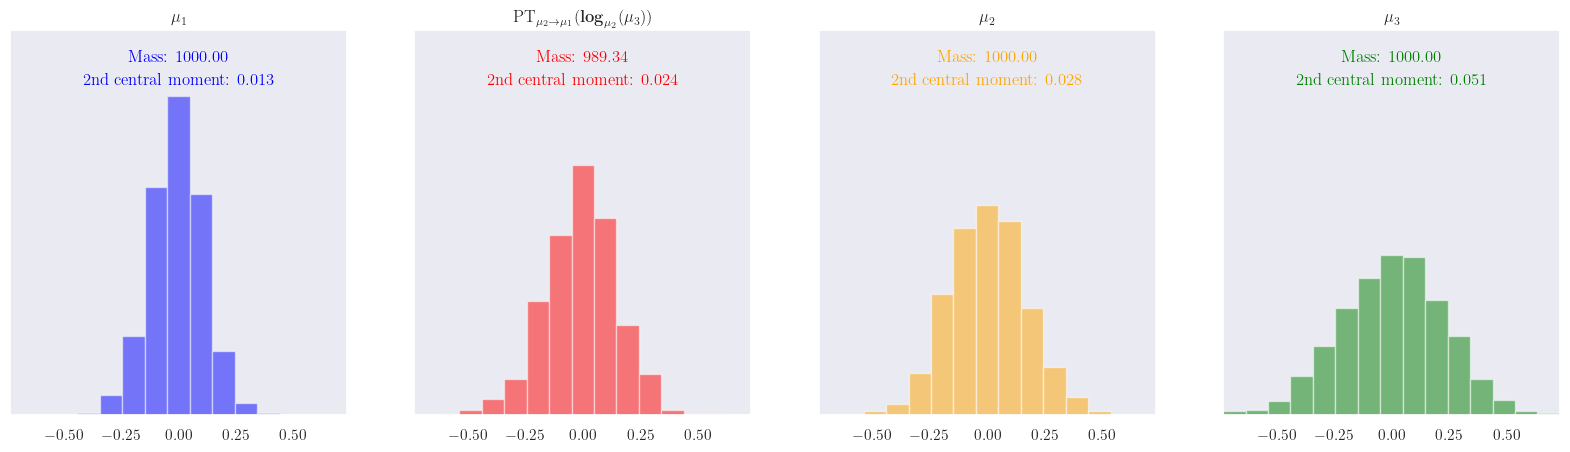

HK distance between mu2 and mu3: 2.2673797949293233
HK distance between mu1 and mu3_at_mu1: 1.8981212478389198


In [5]:
# 1D covariance-change experiment with consistent scaling and diagnostics
n_1 = 1000
n_2 = 1000
n_3 = 1000

mean_1 = np.array([0.0])
cov_1 = np.array([[2.0]])
mean_2 = np.array([0.0])
cov_2 = np.array([[4.0]])
mean_3 = np.array([0.0])
cov_3 = np.array([[8.0]])

rng = np.random.default_rng(1)
data_1 = rng.multivariate_normal(mean_1, cov_1, n_1)
data_2 = rng.multivariate_normal(mean_2, cov_2, n_2)
data_3 = rng.multivariate_normal(mean_3, cov_3, n_3)

# Scale everything to stay inside the cone geometry regime.
max_val = max(np.max(data_1), np.max(data_2), np.max(data_3))
min_val = min(np.min(data_1), np.min(data_2), np.min(data_3))
scale_factor = ((np.pi / 2) - 1e-1) / (max_val - min_val)

data_1_scaled = data_1 * scale_factor
data_2_scaled = data_2 * scale_factor
data_3_scaled = data_3 * scale_factor

print(f"Scaled mean_1: {mean_1 * scale_factor}, Scaled sigma_1: {np.sqrt(cov_1[0, 0]) * scale_factor}")
print(f"Scaled mean_2: {mean_2 * scale_factor}, Scaled sigma_2: {np.sqrt(cov_2[0, 0]) * scale_factor}")
print(f"Scaled mean_3: {mean_3 * scale_factor}, Scaled sigma_3: {np.sqrt(cov_3[0, 0]) * scale_factor}")

mu1 = hkpt.EmpiricalMeasure(data_1_scaled, weights=np.ones(n_1))
mu2 = hkpt.EmpiricalMeasure(data_2_scaled, weights=np.ones(n_2))
mu3 = hkpt.EmpiricalMeasure(data_3_scaled, weights=np.ones(n_3))

tangent_23 = hkpt.hk_logarithmic_map(
    mu2,
    mu3,
    allow_approximation=True,
    approximation_mode='barycentric',
)

# Log/exp consistency check in the same scaled coordinates.
mu3_at_mu2 = hkpt.hk_exponential_map(mu2, tangent_23)
plt.figure(figsize=(10, 6))
plt.hist(mu3.samples.flatten(), bins=30, weights=mu3.weights, label=r'$\mu_3$', color='green', alpha=0.5)
plt.hist(mu3_at_mu2.samples.flatten(), bins=30, weights=mu3_at_mu2.weights, label=r'$\hat{\mu}_3 = \exp_{\mu_2}(\log_{\mu_2}(\mu_3))$', color='red', alpha=0.5)
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

print(f"mu3 mean: {np.mean(mu3.samples.flatten())}, mu3 var: {np.std(mu3.samples.flatten())}")
print(f"mu3_at_mu2 mean: {np.mean(mu3_at_mu2.samples.flatten())}, mu3_at_mu2 var: {np.std(mu3_at_mu2.samples.flatten())}")

tangent_23_at_mu1, pt_alignment_diag = hkpt.hk_parallel_transport(
    mu2,
    mu1,
    tangent_23,
    N=4,
    return_alignment_diagnostics=True,
)

if pt_alignment_diag['alignment_succeeded']:
    print("Parallel transport alignment succeeded")
else:
    print(f"Parallel transport alignment failed with final alignment error {pt_alignment_diag['nearest_neighbor_distances'].max()}")

mu3_at_mu1 = hkpt.hk_exponential_map(mu1, tangent_23_at_mu1)

fig, axs = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
all_hist_samples = [
    mu1.samples.flatten(),
    mu2.samples.flatten(),
    mu3.samples.flatten(),
]
if mu3_at_mu1 is not None:
    all_hist_samples.append(mu3_at_mu1.samples.flatten())
combined_samples = np.concatenate(all_hist_samples)
shared_bins = np.linspace(combined_samples.min(), combined_samples.max(), 16)

subplot_measures = [
    (axs[0], mu1.samples.flatten(), mu1.weights, r'$\mu_1$', 'blue'),
    (axs[1], mu3_at_mu1.samples.flatten() if mu3_at_mu1 is not None else np.array([]), mu3_at_mu1.weights if mu3_at_mu1 is not None else np.array([]), r'$\mathrm{PT}_{\mu_2 \rightarrow \mu_1}(\mathbf{log}_{\mu_2}(\mu_3))$', 'red'),
    (axs[2], mu2.samples.flatten(), mu2.weights, r'$\mu_2$', 'orange'),
    (axs[3], mu3.samples.flatten(), mu3.weights, r'$\mu_3$', 'green'),
]

for ax, samples, weights, title, color in subplot_measures:
    if samples.size:
        ax.hist(samples, bins=shared_bins, weights=weights, color=color, alpha=0.5)
    ax.set_title(title)
    ax.set_yticks([])
    ax.grid(False)

plt.ylim(0, plt.ylim()[1] * 1.15)

def weighted_second_moment(samples, weights):
    w = np.asarray(weights, dtype=float)
    w = w / np.sum(w)
    x = np.asarray(samples, dtype=float)
    m = np.sum(w * x)
    return np.sum(w * (x - m) ** 2)

axs[0].text(0.5, 0.92, f"Mass: {mu1.weights.sum():.2f}", transform=axs[0].transAxes, color='blue', ha='center')
axs[2].text(0.5, 0.92, f"Mass: {mu2.weights.sum():.2f}", transform=axs[2].transAxes, color='orange', ha='center')
axs[3].text(0.5, 0.92, f"Mass: {mu3.weights.sum():.2f}", transform=axs[3].transAxes, color='green', ha='center')
if mu3_at_mu1 is not None:
    axs[1].text(0.5, 0.92, f"Mass: {mu3_at_mu1.weights.sum():.2f}", transform=axs[1].transAxes, color='red', ha='center')

axs[0].text(0.5, 0.86, f"2nd central moment: {weighted_second_moment(mu1.samples.flatten(), mu1.weights):.3f}", transform=axs[0].transAxes, color='blue', ha='center')
axs[2].text(0.5, 0.86, f"2nd central moment: {weighted_second_moment(mu2.samples.flatten(), mu2.weights):.3f}", transform=axs[2].transAxes, color='orange', ha='center')
axs[3].text(0.5, 0.86, f"2nd central moment: {weighted_second_moment(mu3.samples.flatten(), mu3.weights):.3f}", transform=axs[3].transAxes, color='green', ha='center')
if mu3_at_mu1 is not None:
    axs[1].text(0.5, 0.86, f"2nd central moment: {weighted_second_moment(mu3_at_mu1.samples.flatten(), mu3_at_mu1.weights):.3f}", transform=axs[1].transAxes, color='red', ha='center')

max_abs_x = np.max(np.abs(combined_samples))
for ax in axs:
    ax.set_xlim(-max_abs_x, max_abs_x)

plt.savefig(f'../Figures/HK_parallel_transport_1d_cov_change.pdf', dpi=800)
plt.show()

hk_distance_mu2_mu3 = hkpt.hk_distance(mu2, mu3)
hk_distance_mu1_mu3_at_mu1 = hkpt.hk_distance(mu1, mu3_at_mu1)
print(f"HK distance between mu2 and mu3: {hk_distance_mu2_mu3}")
print(f"HK distance between mu1 and mu3_at_mu1: {hk_distance_mu1_mu3_at_mu1}")